# GAN Implementation and Variants

This notebook translates the adversarial formulation into a compact PyTorch implementation. As in the VAE notebook, the purpose is pedagogical clarity rather than state-of-the-art performance. We use a simple multilayer perceptron generator and discriminator on `FashionMNIST`, which is enough to expose the alternating optimization pattern, the role of latent noise, and the difference between discriminator and generator objectives. Once these mechanics are clear, convolutional GANs and stronger image synthesis pipelines become much easier to read.

The main conceptual difference from the VAE implementation is that there is no explicit likelihood or ELBO to evaluate. Instead, the training loop alternates between two objectives. The discriminator updates its parameters to separate real and generated images. The generator then updates its parameters so that the current discriminator assigns large realism scores to generated samples. This means that the loss is not static: it changes throughout training because the critic itself is learned.

For live teaching, it is useful to state the expectations up front. This notebook is not meant to produce state-of-the-art samples, and it is not a benchmark recipe. Its purpose is to make the adversarial mechanics visible enough that students can connect the code directly to the theory chapter. In particular, the alternating optimization pattern, the use of detached fake samples during the discriminator update, and the distinction between minimax and non-saturating generator training are all easier to understand in code than in equations alone.

The notebook also provides a good setting for discussing why GAN engineering became such a large subfield. Even with a small MLP and a small dataset, tiny changes in normalization, optimizer settings, network balance, or data scaling can alter the training behavior noticeably. Rather than hiding this fragility, we will use it as part of the lesson. Students should leave the notebook understanding not only how to implement a GAN, but also why adversarial optimization is more temperamental than standard supervised learning.

## Imports and Dataset

We again choose `FashionMNIST` because it is small, grayscale, and diverse enough to show both partial success and partial failure. This is useful in class because students can see that adversarial training sometimes produces sharp local texture earlier than a VAE, while still suffering from instability and imperfect coverage of the data distribution.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchvision import datasets, transforms, utils
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
if device.type == "cuda":
    torch.cuda.manual_seed_all(7)
num_workers = 0
project_root = Path.cwd() if (Path.cwd() / "_config.yml").exists() else Path.cwd().parent
DATA_ROOT = project_root / "data"

# DCGAN-style settings are still teachable but produce much better samples.
latent_dim = 128
base_channels = 64
batch_size = 128
lr = 2e-4
epochs = 50

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 2.0 * x - 1.0),
])

train_dataset = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)

The hyperparameters here are intentionally conservative for a convolutional GAN. A latent dimension of 128 is large enough to permit variety without making the generator unnecessarily hard to train in a classroom example. The learning rate and Adam coefficients follow long-standing GAN heuristics rather than a theorem. This is worth saying explicitly: part of GAN literacy is learning to distinguish which choices come from mathematical derivation and which come from community practice.

## Generator and Discriminator

The generator maps latent noise $\boldsymbol{z} \sim \mathcal{N}(\boldsymbol{0}, \boldsymbol{I})$ to an image-shaped tensor. The discriminator receives an image and returns a scalar logit. We do not apply a final sigmoid inside the discriminator because `binary_cross_entropy_with_logits` is numerically more stable when working directly with logits. In the generator we apply a final `tanh`, so the dataset transform rescales training images from $[0,1]$ to $[-1,1]$.

In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim=128, base_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, base_channels * 4 * 7 * 7),
            nn.BatchNorm1d(base_channels * 4 * 7 * 7),
            nn.ReLU(True),
            nn.Unflatten(1, (base_channels * 4, 7, 7)),
            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(True),
            nn.Conv2d(base_channels, 1, kernel_size=3, padding=1),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, base_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, base_channels, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(base_channels * 2 * 7 * 7, 1),
        )

    def forward(self, x):
        return self.net(x)


G = Generator(latent_dim=latent_dim, base_channels=base_channels).to(device)
D = Discriminator(base_channels=base_channels).to(device)

g_optimizer = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

The choice of Adam with $\beta_1 = 0.5$ is a traditional GAN heuristic. It is not a theorem, but a practical convention that often helps stabilize the adversarial updates. The deeper pedagogical point is that GANs are sensitive to optimization details to a much greater extent than plain supervised models. This is one reason why code examples matter so much in this part of the course.

The architecture is still simple enough that each block remains interpretable, but it uses the spatial inductive bias that image generation needs. This is a better classroom default than a flattened MLP because students can see the adversarial game while the samples are also good enough to inspect seriously.

## Adversarial Losses

We use the non-saturating generator loss discussed in the theory notebook. The discriminator is trained with binary cross-entropy to classify real images as real and generated images as fake. The generator is trained to maximize the probability that generated images are classified as real. In code, this means that generated images are paired with a target label of one during the generator step.

In [3]:
def discriminator_loss(real_logits, fake_logits):
    # Mild one-sided label smoothing usually stabilizes the discriminator.
    real_targets = torch.full_like(real_logits, 0.9)
    fake_targets = torch.zeros_like(fake_logits)

    real_loss = F.binary_cross_entropy_with_logits(real_logits, real_targets)
    fake_loss = F.binary_cross_entropy_with_logits(fake_logits, fake_targets)
    return real_loss + fake_loss


def generator_loss(fake_logits):
    # Non-saturating loss: the generator wants fake samples judged as real.
    real_targets = torch.ones_like(fake_logits)
    return F.binary_cross_entropy_with_logits(fake_logits, real_targets)

This pair of functions maps directly onto the theory. The discriminator loss combines one term for real images and one for fake images. The generator loss is the non-saturating alternative, so fake logits are compared against a target of one. In words, the generator is trained as if its own samples ought to be classified as real. Students often find this clearer when said explicitly: the generator never sees real images directly in its loss. It only sees how the discriminator currently reacts to its own outputs.

If one wanted to implement the literal minimax generator objective instead, the code would be very short to change. The theory notebook explains why we usually do not make that change in practice. This is an excellent point to encourage students to modify the loss and compare the training behavior themselves later, even if the main course notes avoid turning every notebook into an exercise sheet.

## Training Loop

The alternating structure is the essential new ingredient. For each minibatch, we first update the discriminator using both real and fake samples. The fake samples are detached during the discriminator step so that gradients do not flow back into the generator prematurely. We then sample a fresh batch of latent vectors and update the generator using the current discriminator. This is a simple instance of a two-time-scale game, even though we use one discriminator step and one generator step per batch here.

In [6]:
history = {"d_loss": [], "g_loss": []}


fixed_z = torch.randn(16, latent_dim, device=device)

for epoch in tqdm(range(epochs), desc="GAN epochs"):
    d_running = 0.0
    g_running = 0.0

    for real_images, _ in tqdm(train_loader, desc="train", leave=False):
        real_images = real_images.to(device)
        batch_n = real_images.size(0)

        # First update the discriminator on real and detached fake samples.
        z = torch.randn(batch_n, latent_dim, device=device)
        fake_images = G(z)

        d_optimizer.zero_grad()
        real_logits = D(real_images)
        fake_logits = D(fake_images.detach())
        d_loss = discriminator_loss(real_logits, fake_logits)
        d_loss.backward()
        d_optimizer.step()

        # Then update the generator against the current discriminator.
        z = torch.randn(batch_n, latent_dim, device=device)
        fake_images = G(z)

        g_optimizer.zero_grad()
        fake_logits = D(fake_images)
        g_loss = generator_loss(fake_logits)
        g_loss.backward()
        g_optimizer.step()

        d_running += d_loss.item()
        g_running += g_loss.item()

    d_epoch = d_running / len(train_loader)
    g_epoch = g_running / len(train_loader)
    history["d_loss"].append(d_epoch)
    history["g_loss"].append(g_epoch)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"D loss: {d_epoch:.4f} | "
        f"G loss: {g_epoch:.4f}"
    )

GAN epochs:   0%|          | 0/50 [00:00<?, ?it/s]

train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | D loss: 0.8697 | G loss: 1.7760


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 02 | D loss: 0.8901 | G loss: 1.6614


...

Epoch 48 | D loss: 1.2689 | G loss: 1.0341


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 49 | D loss: 1.2689 | G loss: 1.0319


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 50 | D loss: 1.2679 | G loss: 1.0327


There are several details here that are worth highlighting aloud in a lecture. First, we draw a fresh latent batch for the generator step instead of reusing the exact same noise vectors as in the discriminator step. This is not logically necessary, but it makes the two updates conceptually distinct. Second, the call to `detach()` is crucial. Without it, the discriminator update would also backpropagate into the generator graph, mixing the roles of the two players. Third, the discriminator sees image tensors directly because the convolutional architecture uses spatial structure.

More advanced GAN implementations often use unequal numbers of discriminator and generator updates, gradient penalties, exponential moving averages of generator weights, or larger batches. These additions can matter a great deal in realistic image synthesis. The minimal loop here should therefore be read as the bare skeleton of adversarial optimization, not as a universal recipe.

These losses must be interpreted with care. In supervised learning, lower validation loss usually has a fairly stable meaning. In GANs, discriminator and generator losses can oscillate, flatten, or even move in apparently counterintuitive directions while sample quality changes. This is because the objective is relative: a strong discriminator can make the generator loss high even when the samples are improving, and vice versa. For that reason, one should always inspect generated images rather than rely only on scalar losses.

A useful classroom warning is that a discriminator loss near zero is not automatically a victory, and a generator loss that increases is not automatically a disaster. If the discriminator becomes too strong too early, the generator may stop receiving helpful information. Conversely, a temporary rise in generator loss may simply mean that the critic has improved its standards. Scalar curves still matter, but mainly as contextual signals rather than as standalone performance scores. The most trustworthy diagnosis usually combines loss trajectories, visual samples, and knowledge of the training setup.

## Sampling and Visual Inspection

The simplest diagnostic is to sample from the generator at regular intervals and inspect the resulting image grid. Since the generator outputs values in $[-1,1]$, we rescale them back to $[0,1]$ for display. In a classroom setting it is useful to compare these images against the VAE samples from the previous notebook and discuss the tradeoff between sharpness, stability, and coverage.

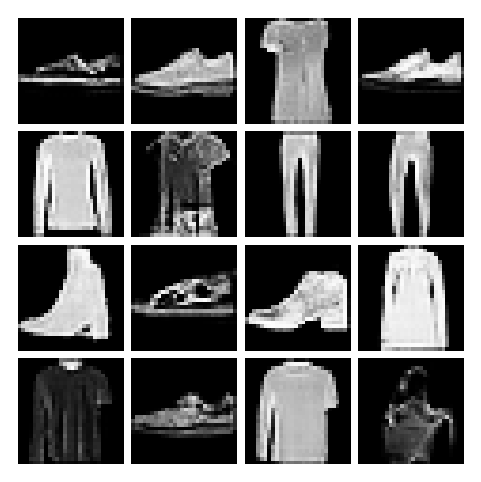

In [7]:
@torch.no_grad()
def show_gan_samples(generator, device, n=16):
    generator.eval()
    z = fixed_z[:n] if n <= fixed_z.size(0) else torch.randn(n, latent_dim, device=device)
    samples = generator(z).view(-1, 1, 28, 28)
    # Undo tanh scaling for display.
    samples = 0.5 * (samples + 1.0)
    image = utils.make_grid(samples.cpu(), nrow=4, pad_value=1.0)
    plt.figure(figsize=(6, 6))
    plt.imshow(image.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()
    generator.train()


show_gan_samples(G, device)

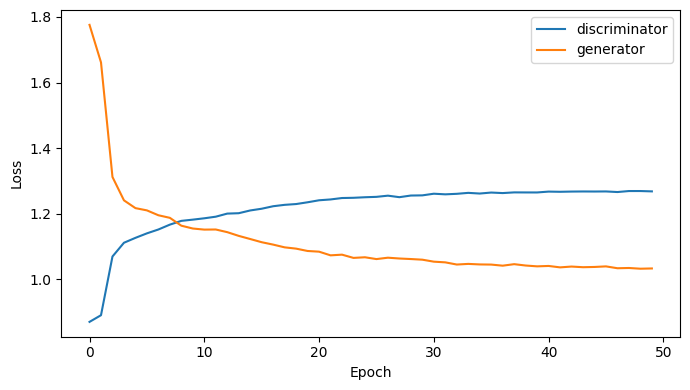

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(history["d_loss"], label="discriminator")
plt.plot(history["g_loss"], label="generator")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

When this notebook works reasonably well, one should expect the generator to move from amorphous noise toward recognizable clothing silhouettes, often with sharper edges than a comparably small VAE produces. At the same time, one should also expect imperfections: repeated shapes, missing classes, unstable textures, or sensitivity to random initialization. Those imperfections are not incidental. They are part of what the notebook is meant to teach.

If training fails badly, a few debugging clues are especially common. If all samples look nearly identical, suspect mode collapse or an overpowered discriminator. If both losses oscillate wildly and samples never improve, learning rates may be too large or the network balance may be poor. If samples remain pure noise while the discriminator loss drops immediately, the discriminator may be learning too fast relative to the generator. These are not exhaustive diagnoses, but they help students see adversarial training as something one interprets dynamically rather than passively runs.

## Quantitative Evaluation with FID and KID

GANs are the model family where quantitative image metrics often become especially important. A GAN can produce very sharp samples while still missing modes of the true data distribution. FID and KID help us ask whether the generated image *distribution* resembles the real one, not merely whether a few hand-picked samples look good.

As in the VAE notebook, the values below should be treated as classroom diagnostics rather than benchmark-grade results. The dataset is small, the architecture is intentionally minimal, and the generated images are grayscale, so we adapt them to the expected three-channel format before feature extraction.

In [9]:
def prepare_for_inception_metrics(images):
    if images.size(1) == 1:
        images = images.repeat(1, 3, 1, 1)
    return images.clamp(0.0, 1.0)


@torch.no_grad()
def compute_gan_fid_and_kid(generator, real_loader, device, num_fake=1000):
    fid = FrechetInceptionDistance(
        feature=2048,
        normalize=True,
        reset_real_features=False,
    ).set_dtype(torch.float64).to(device)
    kid = KernelInceptionDistance(
        feature=2048,
        subsets=10,
        subset_size=100,
        normalize=True,
        reset_real_features=False,
    ).to(device)

    for real_images, _ in tqdm(real_loader, desc="real metrics", leave=False):
        real_images = prepare_for_inception_metrics(0.5 * (real_images.to(device) + 1.0))
        fid.update(real_images, real=True)
        kid.update(real_images, real=True)

    generated = 0
    pbar = tqdm(total=num_fake, desc="GAN fake metrics", leave=False)
    while generated < num_fake:
        batch_n = min(batch_size, num_fake - generated)
        z = torch.randn(batch_n, latent_dim, device=device)
        fake_images = generator(z).view(-1, 1, 28, 28)
        # Undo tanh scaling so the metric sees images in [0, 1].
        fake_images = 0.5 * (fake_images + 1.0)
        fake_images = prepare_for_inception_metrics(fake_images)
        fid.update(fake_images, real=False)
        kid.update(fake_images, real=False)
        generated += batch_n
        pbar.update(batch_n)
    pbar.close()

    kid_mean, kid_std = kid.compute()
    return {
        "fid": fid.compute().item(),
        "kid_mean": kid_mean.item(),
        "kid_std": kid_std.item(),
    }


metric_scores = compute_gan_fid_and_kid(G, train_loader, device)
print(metric_scores)

c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


real metrics:   0%|          | 0/469 [00:00<?, ?it/s]

GAN fake metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

{'fid': 27.91730294735345, 'kid_mean': 0.009366440586745739, 'kid_std': 0.003037596819922328}


This metric block is especially useful for discussing **mode collapse**. A GAN may improve visually while still obtaining disappointing FID or KID if it allocates mass too narrowly over the dataset. That makes these scores a nice complement to image grids: the image grid shows local sharpness, while FID and KID say something more about global coverage.

## Variant Notes

The implementation above is intentionally minimal, but it also exposes the main weaknesses of the vanilla GAN. If training oscillates or samples collapse to a narrow subset of patterns, this is not an accident but a characteristic of the original adversarial game. Three influential corrections are worth keeping in mind.

In Wasserstein GANs, the discriminator is replaced by a critic that outputs unrestricted real values rather than probabilities. The training objective changes so that the critic approximates the Wasserstein-1 distance between real and generated distributions. This often produces smoother gradients, especially when the two supports overlap poorly. In spectral normalization GANs, each linear or convolutional layer of the discriminator is normalized by an estimate of its spectral norm. This controls the layer-wise Lipschitz constant and tends to improve stability with minimal code changes. In CycleGAN, the adversarial mechanism is used in a conditional translation setting where one learns mappings between two domains without paired examples; the cycle-consistency term is then what prevents arbitrary mappings that fool the discriminator but destroy semantic content.

From the perspective of code evolution, these variants tell a useful story. WGAN changes the loss and the meaning of the critic output. Spectral normalization changes the architecture while leaving much of the outer training loop intact. CycleGAN changes the task itself by introducing domain-conditioned generators, two discriminators, and additional reconstruction structure. Seeing these as different axes of modification helps students avoid the impression that every new GAN paper is a totally unrelated invention. Many are targeted interventions on one of three objects: the objective, the critic class, or the problem structure.

The deeper lesson from this notebook is that GANs are simple to state but delicate to optimize. The code is shorter than a VAE implementation because there is no explicit inference model or ELBO, yet the practical behavior is often harder to control. This is an excellent opportunity to emphasize to students that conceptual brevity and optimization ease are not the same thing.